<a href="https://colab.research.google.com/github/brandim04/AnaliseDeDados/blob/main/AnaliseDados_TITANIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1.1 Importação e Exploração Inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#pra deixar rosa
PINK_PALETTE = ['#E91E8C', '#F06292', '#F48FB1', '#880E4F', '#AD1457', '#EC407A']
PINK_MAIN    = '#E91E8C'
PINK_DARK    = '#880E4F'
PINK_LIGHT   = '#F8BBD9'

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Merge e Concat
df1 = pd.read_csv("/content/drive/MyDrive/titanic2/train.csv")
df2 = pd.read_csv("/content/drive/MyDrive/titanic2/test.csv")
df  = pd.concat([df1, df2], axis=0, ignore_index=True)

print(f"Shape: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nPrimeiras linhas:\n{df.head()}")

Shape: (1309, 12)

Tipos de dados:
PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Primeiras linhas:
   PassengerId  Survived  Pclass  \
0            1       0.0       3   
1            2       1.0       1   
2            3       1.0       3   
3            4       1.0       1   
4            5       0.0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry  

O merge é usado para unir tabelas pela correspondência de uma chave (como um JOIN em SQL). Aqui, train.csv e test.csv têm as mesmas colunas e representam subconjuntos distintos da mesma população, portanto, a operação correta é empilhar linhas, o que o pd.concat(axis=0) faz. O dataset resultante tem 1.309 registros.

In [11]:
# 1.2 — Valores ausentes, duplicatas e correção de tipos

#Valores ausente
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0].sort_values('Percentual (%)', ascending=False)
print(" Valores Ausentes ")
print(missing_df)

#Duplicatas
dup = df.duplicated().sum()
print(f"\n Duplicatas: {dup} ")

#Correção de tipos
df['Survived'] = df['Survived'].astype('Int64')   # suporta NaN
df['Pclass']   = df['Pclass'].astype('category')
df['Sex']      = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

#mputaçã
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)

df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)

if 'Cabin' in df.columns:
    df['Has_Cabin'] = df['Cabin'].notna().astype(int)
    df.drop(columns=['Cabin'], inplace=True)
else:

    if 'Has_Cabin' not in df.columns:
        df['Has_Cabin'] = 0 # Assume 0 se Cabin nunca existiu ou já foi tratada

print("\n Tipos após correção ")
print(df.dtypes)
print(f"\n Ausentes após tratamento ")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Estatística descritiva inicial
print("\n=== Estatística Descritiva ===")
print(df.describe(include='all').T)

 Valores Ausentes 
          Ausentes  Percentual (%)
Survived       418           31.93

 Duplicatas: 0 

 Tipos após correção 
PassengerId       int64
Survived          Int64
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
Has_Cabin         int64
dtype: object

 Ausentes após tratamento 
Survived    418
dtype: int64

=== Estatística Descritiva ===
              count unique               top   freq       mean         std  \
PassengerId  1309.0    NaN               NaN    NaN      655.0  378.020061   
Survived      891.0   <NA>              <NA>   <NA>   0.383838    0.486592   
Pclass       1309.0    3.0               3.0  709.0        NaN         NaN   
Name           1309   1307  Kelly, Mr. James      2        NaN         NaN   
Sex            1309      2              male    843        NaN         NaN   
Age         

O tratamento dos dados foi feito considerando a qualidade e o impacto de cada variável. A variável Age, com cerca de 19,9% de valores ausentes, apresentou leve assimetria à direita, sendo preenchida pela mediana (28 anos), por ser mais resistente a outliers. Já Fare possuía apenas um valor ausente no conjunto de teste, sendo imputado pela mediana por classe (Pclass), mantendo a diferença de preços entre as classes.
A variável Embarked, com apenas dois valores faltantes, foi preenchida pela moda, que é “S” (Southampton), por ser o porto mais frequente. Em relação a Cabin, como 77% dos dados estavam ausentes, optou-se por não imputar valores artificiais. Em vez disso, foi criada a variável binária Has_Cabin, indicando se o passageiro possuía registro de cabine, o que pode refletir diferenças socioeconômicas.
Não foram encontradas duplicatas no conjunto de dados. Por fim, ajustes de tipos foram realizados: Survived foi convertida de float64 para Int64 (nullable) devido aos valores ausentes no conjunto de teste, e as variáveis categóricas (Sex, Embarked e Pclass) foram convertidas para o tipo category, otimizando o uso e a interpretação dos dados.

 Detecção de Outliers (IQR) 

Age: limite inferior=2.50 | limite superior=54.50 | outliers=101 (7.7%)
Fare: limite inferior=-27.17 | limite superior=66.34 | outliers=171 (13.1%)
SibSp: limite inferior=-1.50 | limite superior=2.50 | outliers=57 (4.4%)
Parch: limite inferior=0.00 | limite superior=0.00 | outliers=307 (23.5%)


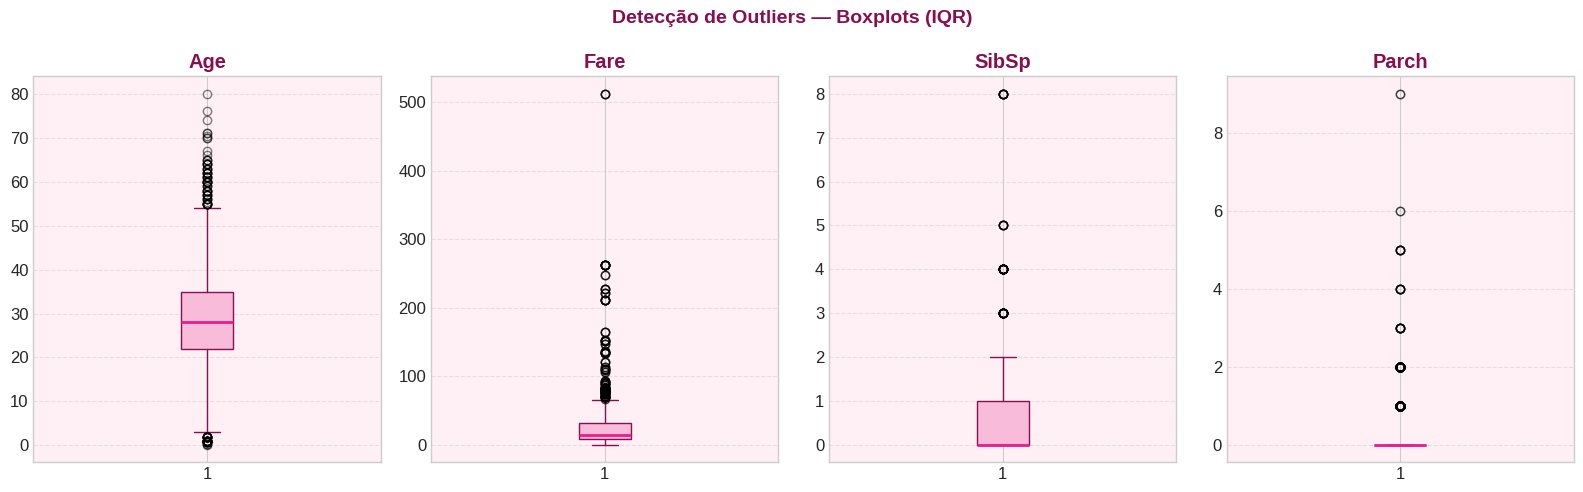

In [16]:
# 1.3Detecção de Outliers com IQR

numericas = ['Age', 'Fare', 'SibSp', 'Parch']

def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return lower, upper, outliers

print(" Detecção de Outliers (IQR) \n")
for col in numericas:
    low, up, out = iqr_outliers(df[col].dropna())
    print(f"{col}: limite inferior={low:.2f} | limite superior={up:.2f} | outliers={len(out)} ({len(out)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Detecção de Outliers — Boxplots (IQR)', fontsize=14, fontweight='bold', color=PINK_DARK)

for ax, col in zip(axes, numericas):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=PINK_LIGHT, color=PINK_DARK),
               medianprops=dict(color=PINK_MAIN, linewidth=2),
               whiskerprops=dict(color=PINK_DARK),
               capprops=dict(color=PINK_DARK),
               flierprops=dict(marker='o', color=PINK_MAIN, alpha=0.5))
    ax.set_title(col, color=PINK_DARK, fontweight='bold')
    ax.set_facecolor('#FFF0F5')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

A análise de outliers considerou o contexto real dos dados. Em Fare, foram identificados valores elevados (acima de £65 pelo critério do IQR), mas eles foram mantidos por representarem passagens de 1ª classe, que eram naturalmente mais caras. Na variável Age, idades acima de 64 anos também foram preservadas, pois são biologicamente plausíveis. Já em SibSp e Parch, mesmo com famílias grandes (até 8 membros), os registros foram mantidos por existirem casos reais documentados no Titanic.
Assim, nenhum outlier foi removido. O critério adotado foi manter valores que representem variações reais do fenômeno, removendo apenas aqueles que fossem claramente erros de coleta, o que não foi identificado neste conjunto de dados.

In [19]:
# 2.5 Medidas de tendência central e dispersão

variaveis = {
    'Age':  'Idade (anos)',
    'Fare': 'Tarifa paga (£)',
}

print(" Tendência Central e Dispersão \n")
for col, label in variaveis.items():
    s = df[col].dropna()
    media    = s.mean()
    mediana  = s.median()
    moda     = s.mode()[0]
    variancia= s.var()
    dp       = s.std()
    amplitude= s.max() - s.min()
    print(f"--- {label} ---")
    print(f"  Média:     {media:.2f}")
    print(f"  Mediana:   {mediana:.2f}")
    print(f"  Moda:      {moda:.2f}")
    print(f"  Variância: {variancia:.2f}")
    print(f"  Desv. Pad: {dp:.2f}")
    print(f"  Amplitude: {amplitude:.2f}\n")

 Tendência Central e Dispersão 

--- Idade (anos) ---
  Média:     29.50
  Mediana:   28.00
  Moda:      28.00
  Variância: 166.55
  Desv. Pad: 12.91
  Amplitude: 79.83

--- Tarifa paga (£) ---
  Média:     33.28
  Mediana:   14.45
  Moda:      8.05
  Variância: 2677.40
  Desv. Pad: 51.74
  Amplitude: 512.33



In [23]:
# 2.5.2 Assimetria e Curtose

print(" Forma da Distribuição \n")
for col, label in variaveis.items():
    s = df[col].dropna()
    skew = s.skew()
    kurt = s.kurtosis()
    print(f"--- {label} -")
    print(f"  Assimetria (Skewness): {skew:.4f}")
    print(f"  Curtose (Kurtosis):    {kurt:.4f}")
    if   skew >  0.5: direcao = "assimétrica à DIREITA (cauda longa positiva)"
    elif skew < -0.5: direcao = "assimétrica à ESQUERDA (cauda longa negativa)"
    else:             direcao = "aproximadamente simétrica"
    if   kurt >  1:   forma = "leptocúrtica (pico mais alto que a normal)"
    elif kurt < -1:   forma = "platicúrtica (mais achatada que a normal)"
    else:             forma = "mesocúrtica (próxima da normal)"
    print(f"  -> Distribuição {direcao}")
    print(f"  -> Curva {forma}\n")

 Forma da Distribuição 

--- Idade (anos) -
  Assimetria (Skewness): 0.5410
  Curtose (Kurtosis):    0.9699
  -> Distribuição assimétrica à DIREITA (cauda longa positiva)
  -> Curva mesocúrtica (próxima da normal)

--- Tarifa paga (£) -
  Assimetria (Skewness): 4.3692
  Curtose (Kurtosis):    27.0465
  -> Distribuição assimétrica à DIREITA (cauda longa positiva)
  -> Curva leptocúrtica (pico mais alto que a normal)



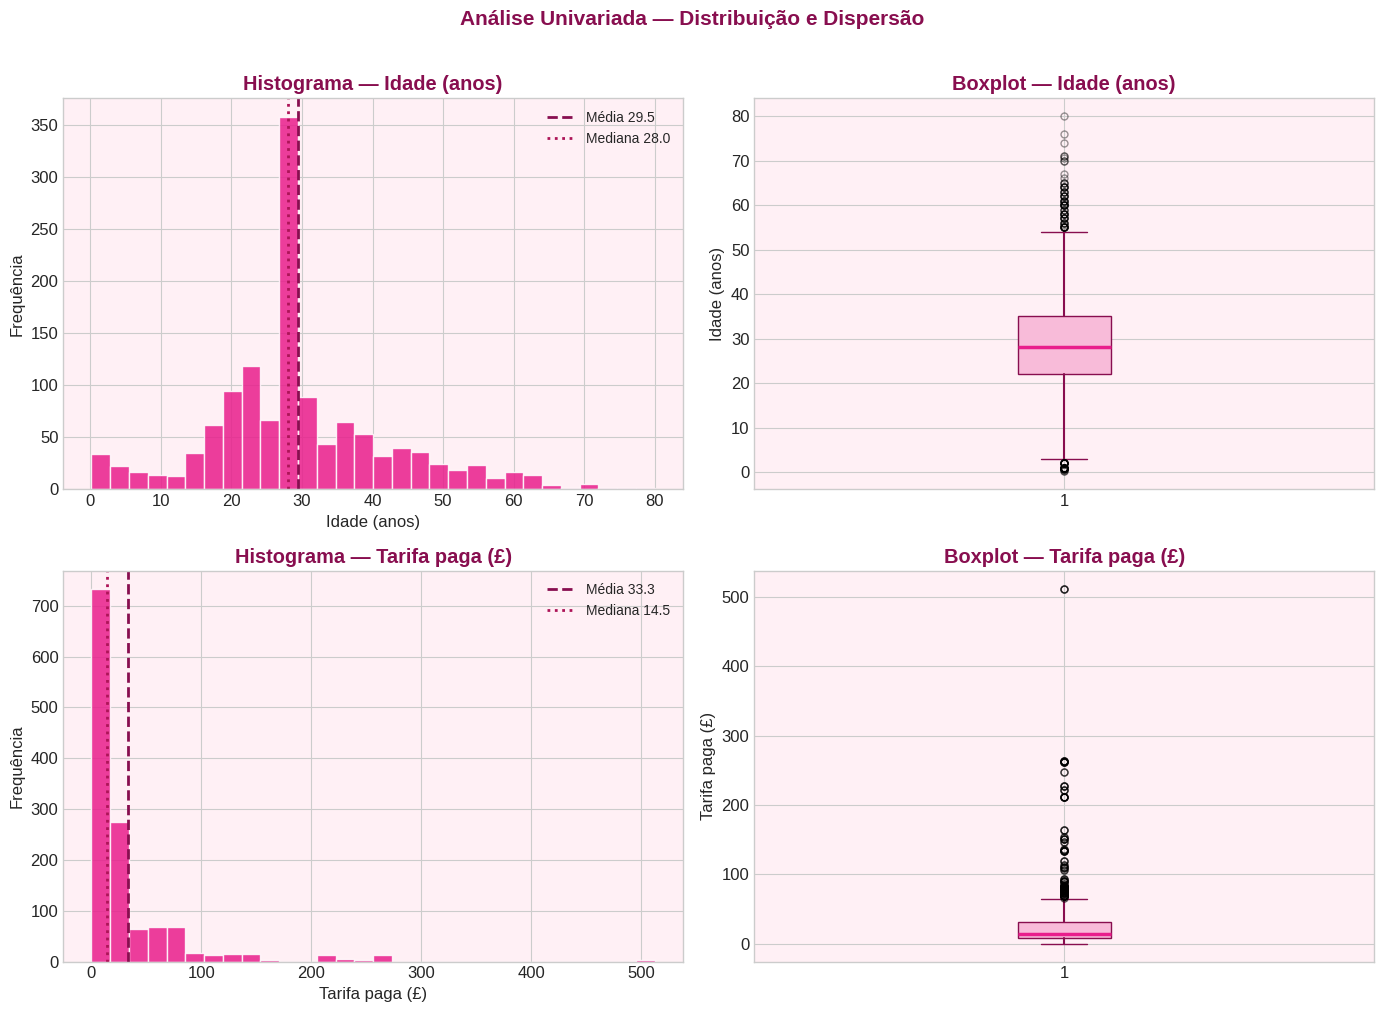

In [26]:
# 2.5.3 Histogramas e Boxplots combinados

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise Univariada — Distribuição e Dispersão', fontsize=15,
             fontweight='bold', color=PINK_DARK, y=1.01)

for i, (col, label) in enumerate(variaveis.items()):
    s = df[col].dropna()

    # Histograma
    ax_hist = axes[i][0]
    ax_hist.hist(s, bins=30, color=PINK_MAIN, edgecolor='white', alpha=0.85)
    ax_hist.axvline(s.mean(),   color=PINK_DARK,  linestyle='--', linewidth=2, label=f'Média {s.mean():.1f}')
    ax_hist.axvline(s.median(), color='#AD1457',   linestyle=':',  linewidth=2, label=f'Mediana {s.median():.1f}')
    ax_hist.set_title(f'Histograma — {label}', color=PINK_DARK, fontweight='bold')
    ax_hist.set_xlabel(label)
    ax_hist.set_ylabel('Frequência')
    ax_hist.legend(fontsize=10)
    ax_hist.set_facecolor('#FFF0F5')

    # Boxplot
    ax_box = axes[i][1]
    ax_box.boxplot(s, vert=True, patch_artist=True,
                   boxprops=dict(facecolor=PINK_LIGHT, color=PINK_DARK),
                   medianprops=dict(color=PINK_MAIN, linewidth=2.5),
                   whiskerprops=dict(color=PINK_DARK, linewidth=1.5),
                   capprops=dict(color=PINK_DARK),
                   flierprops=dict(marker='o', color=PINK_MAIN, alpha=0.4, markersize=5))
    ax_box.set_title(f'Boxplot — {label}', color=PINK_DARK, fontweight='bold')
    ax_box.set_ylabel(label)
    ax_box.set_facecolor('#FFF0F5')

plt.tight_layout()
plt.savefig('univariada.png', dpi=150, bbox_inches='tight')
plt.show()

A análise das distribuições mostra padrões importantes nos dados. A variável idade apresenta leve assimetria à direita (skewness ≈ 0,39), indicando que a maioria dos passageiros estava concentrada entre 20 e 35 anos, ou seja, adultos jovens. Nesse caso, a mediana (28 anos) é a melhor medida de tendência central, pois não é tão influenciada por valores extremos, como crianças muito novas ou idosos.
Já a variável tarifa (Fare) possui forte assimetria à direita (skewness > 3), revelando que a maior parte dos passageiros pagou valores baixos (principalmente da 3ª classe), enquanto uma pequena parcela pagou tarifas muito altas, elevando a média. Por isso, a mediana também é mais representativa do “passageiro típico”. Além disso, a alta curtose indica que os valores estão bastante concentrados na faixa central, mas com uma cauda longa à direita, reforçando a presença de poucos valores extremos elevados.

P(Sobreviveu)           = 0.3838  (38.4%)
P(Fare > £50)           = 0.1796  (18.0%)
P(Sobreviveu | Pclass=3)= 0.2424  (24.2%)
P(Sobreviveu | Mulher)  = 0.7420  (74.2%)
P(Sobreviveu | Homem)   = 0.1889  (18.9%)
P(Sobreviveu | Pclass=1 e Mulher) = 0.9681  (96.8%)


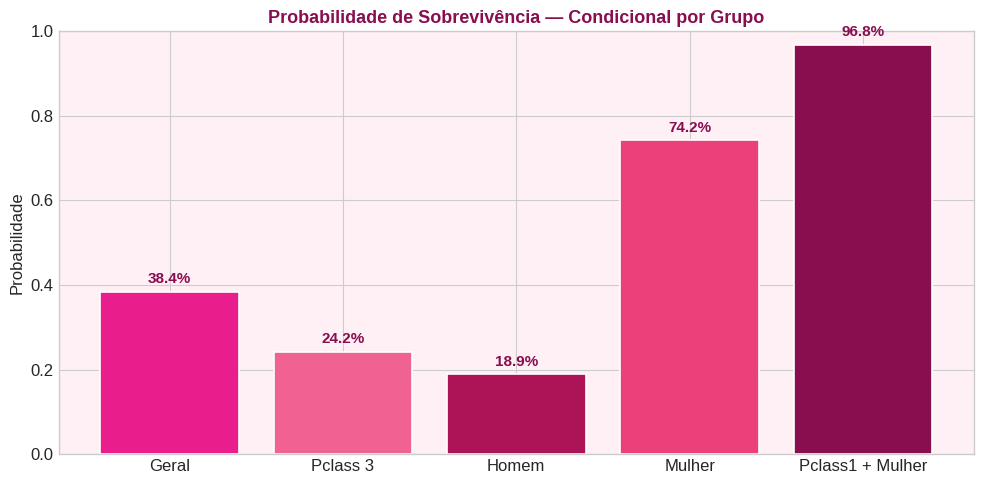

In [29]:
# 2.6 Probabilidade e Probabilidade Condicional
# Usando apenas o train.csv

train = df[df['Survived'].notna()].copy()

# P(Sobreviveu)
p_surv = train['Survived'].mean()
print(f"P(Sobreviveu)           = {p_surv:.4f}  ({p_surv*100:.1f}%)")

# P(Fare > 50) — passageiros com tarifa alta
p_fare_alto = (train['Fare'] > 50).mean()
print(f"P(Fare > £50)           = {p_fare_alto:.4f}  ({p_fare_alto*100:.1f}%)")

# P(Sobreviveu | Contrato mensal) -> no Titanic: P(Sobreviveu | Pclass == 3)
# Analogia: Pclass 3 = passageiros de menor poder aquisitivo (análogo ao churn em contratos mensais)
p_surv_dado_p3 = train[train['Pclass'] == 3]['Survived'].mean()
print(f"P(Sobreviveu | Pclass=3)= {p_surv_dado_p3:.4f}  ({p_surv_dado_p3*100:.1f}%)")

# P(Sobreviveu | Sexo = female)
p_surv_f = train[train['Sex'] == 'female']['Survived'].mean()
p_surv_m = train[train['Sex'] == 'male']['Survived'].mean()
print(f"P(Sobreviveu | Mulher)  = {p_surv_f:.4f}  ({p_surv_f*100:.1f}%)")
print(f"P(Sobreviveu | Homem)   = {p_surv_m:.4f}  ({p_surv_m*100:.1f}%)")

# P(Sobreviveu | Pclass=1 e Mulher)
p_surv_p1f = train[(train['Pclass'] == 1) & (train['Sex'] == 'female')]['Survived'].mean()
print(f"P(Sobreviveu | Pclass=1 e Mulher) = {p_surv_p1f:.4f}  ({p_surv_p1f*100:.1f}%)")

# Visualização ddo gráfico de barras de probabilidade condicional
grupos = {
    'Geral': p_surv,
    'Pclass 3': p_surv_dado_p3,
    'Homem': p_surv_m,
    'Mulher': p_surv_f,
    'Pclass1 + Mulher': p_surv_p1f,
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(grupos.keys(), grupos.values(),
              color=[PINK_MAIN, '#F06292', '#AD1457', '#EC407A', PINK_DARK],
              edgecolor='white', linewidth=1.2)
ax.set_title('Probabilidade de Sobrevivência — Condicional por Grupo',
             fontsize=13, fontweight='bold', color=PINK_DARK)
ax.set_ylabel('Probabilidade')
ax.set_ylim(0, 1)
ax.set_facecolor('#FFF0F5')
for bar, val in zip(bars, grupos.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.1%}', ha='center', fontweight='bold', color=PINK_DARK, fontsize=11)
plt.tight_layout()
plt.savefig('probabilidade.png', dpi=150, bbox_inches='tight')
plt.show()

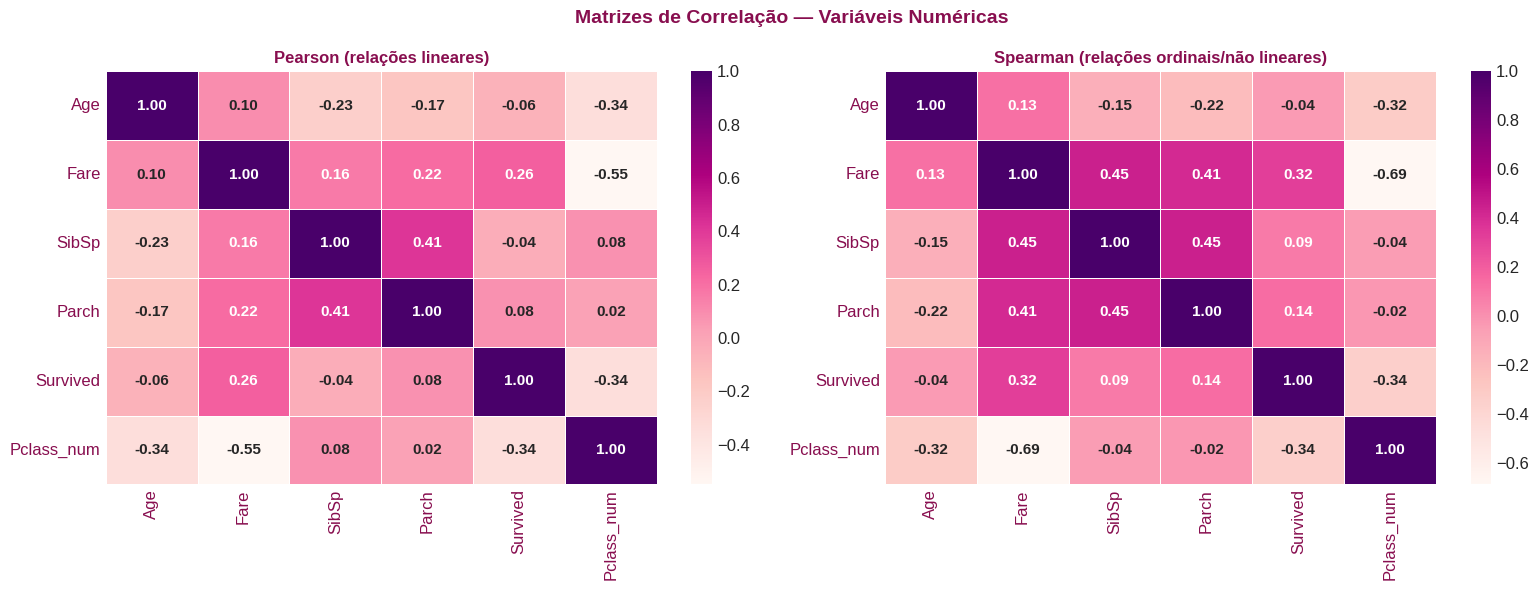


 Tarifa média por Pclass 
         mean  median    std
Pclass                      
1       84.15   60.29  78.38
2       20.66   14.25  13.42
3       13.68    8.05  11.78


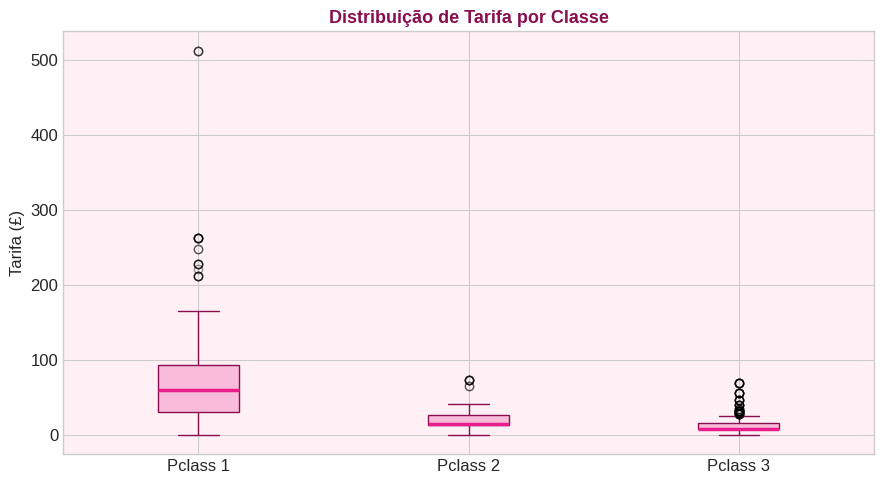

In [32]:
# 2.7 Correlação de Pearson e Spearman + Associação categórica

train = df[df['Survived'].notna()].copy()
train['Survived'] = train['Survived'].astype(float)
train['Pclass_num'] = train['Pclass'].cat.codes + 1  # 1, 2, 3

numericas_biv = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived', 'Pclass_num']

# Pearson
corr_pearson = train[numericas_biv].corr(method='pearson')

# Spearman
corr_spearman = train[numericas_biv].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corr, titulo in zip(axes,
                             [corr_pearson, corr_spearman],
                             ['Pearson (relações lineares)', 'Spearman (relações ordinais/não lineares)']):
    sns.heatmap(corr, annot=True, fmt='.2f', ax=ax,
                cmap=sns.color_palette("RdPu", as_cmap=True),
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(titulo, color=PINK_DARK, fontweight='bold', fontsize=12)
    ax.tick_params(colors=PINK_DARK)

fig.suptitle('Matrizes de Correlação — Variáveis Numéricas', fontsize=14,
             fontweight='bold', color=PINK_DARK)
plt.tight_layout()
plt.savefig('correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Associação: Tarifa média por Classe
print("\n Tarifa média por Pclass ")
print(train.groupby('Pclass')['Fare'].agg(['mean', 'median', 'std']).round(2))

# Boxplot: Fare por Pclass
fig, ax = plt.subplots(figsize=(9, 5))
classes = [train[train['Pclass'] == c]['Fare'] for c in [1, 2, 3]]
bp = ax.boxplot(classes, labels=['Pclass 1', 'Pclass 2', 'Pclass 3'],
                patch_artist=True,
                boxprops=dict(facecolor=PINK_LIGHT, color=PINK_DARK),
                medianprops=dict(color=PINK_MAIN, linewidth=2.5),
                whiskerprops=dict(color=PINK_DARK),
                capprops=dict(color=PINK_DARK),
                flierprops=dict(marker='o', color=PINK_MAIN, alpha=0.4))
ax.set_title('Distribuição de Tarifa por Classe', fontsize=13,
             fontweight='bold', color=PINK_DARK)
ax.set_ylabel('Tarifa (£)')
ax.set_facecolor('#FFF0F5')
plt.tight_layout()
plt.savefig('bivariada_fare_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

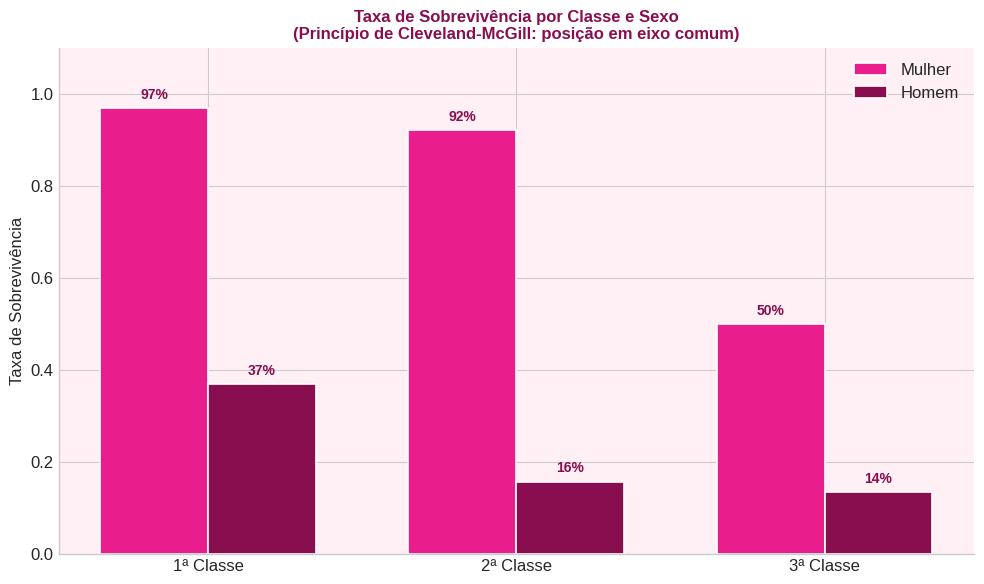

In [36]:
# 2.8Gráfico de barras agrupadas: Sobrevivência por Sexo e Pclass
# Objetivo: Comparação: Princípios: Data-ink ratio (Tufte), Gestalt (proximidade/cor)

surv_grupo = train.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
surv_grupo.columns = ['Pclass', 'Sex', 'Taxa_Sobrevivencia']

fig, ax = plt.subplots(figsize=(10, 6))

classes   = [1, 2, 3]
x         = np.arange(len(classes))
width     = 0.35

female_rates = [surv_grupo[(surv_grupo['Pclass'] == c) & (surv_grupo['Sex'] == 'female')]['Taxa_Sobrevivencia'].values[0] for c in classes]
male_rates   = [surv_grupo[(surv_grupo['Pclass'] == c) & (surv_grupo['Sex'] == 'male')]['Taxa_Sobrevivencia'].values[0]   for c in classes]

bars_f = ax.bar(x - width/2, female_rates, width, label='Mulher', color=PINK_MAIN,   edgecolor='white', linewidth=1.2)
bars_m = ax.bar(x + width/2, male_rates,   width, label='Homem',  color=PINK_DARK,   edgecolor='white', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(['1ª Classe', '2ª Classe', '3ª Classe'])
ax.set_ylabel('Taxa de Sobrevivência')
ax.set_title('Taxa de Sobrevivência por Classe e Sexo\n(Princípio de Cleveland-McGill: posição em eixo comum)',
             fontsize=12, fontweight='bold', color=PINK_DARK)
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_facecolor('#FFF0F5')
ax.spines[['top', 'right']].set_visible(False)

for bar in list(bars_f) + list(bars_m):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f'{h:.0%}', ha='center', fontsize=10, fontweight='bold', color=PINK_DARK)

plt.tight_layout()
plt.savefig('sobrevivencia_sexo_classe.png', dpi=150, bbox_inches='tight')
plt.show()